In [1]:
# Cell 1 – Imports and helper functions
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from tqdm.auto import tqdm
import re
import time

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

def compute_module_averages(proteome_df, protein_to_module, modules):
    """
    Compute average log2 fold change for each module across all deletions.

    proteome_df : DataFrame (rows: deletion strains, columns: proteins, values: log2 ratios)
    protein_to_module : dict mapping protein ORF -> module index
    modules : list or set of module indices
    """
    module_to_proteins = {m: [] for m in modules}
    for protein, module in protein_to_module.items():
        if module in module_to_proteins:
            module_to_proteins[module].append(protein)

    module_avgs = pd.DataFrame(index=proteome_df.index, columns=modules)
    for m in modules:
        proteins_in_module = module_to_proteins[m]
        proteins_in_module = [p for p in proteins_in_module if p in proteome_df.columns]
        if proteins_in_module:
            module_avgs[m] = proteome_df[proteins_in_module].mean(axis=1)
        else:
            module_avgs[m] = np.nan
    return module_avgs

def map_uniprot_to_orf(uniprot_ids):
    """
    Map a list of UniProt accessions to yeast ORF names.
    It first tries the bioservices UniProt mapping; if that fails, it falls back to
    the UniProt REST API.  Only ORFs matching the pattern Yxx###C/W are returned.
    """
    mapping = {}
    try:
        from bioservices import UniProt
        u = UniProt()
        # Use UniProt mapping service: ACC → ORFNAME
        result = u.mapping(fr="ACC", to="ORFNAME", query=uniprot_ids)
        # result is dict accession -> list of ORF names; take the first if matches pattern
        for acc, orfs in result.items():
            for orf in orfs:
                if re.match(r"Y[A-Z]{2}\d{3}[CW]", orf):
                    mapping[acc] = orf
                    break
    except Exception:
        # Fallback: use UniProt REST API for batches
        url = "https://rest.uniprot.org/uniprotkb/stream"
        for i in range(0, len(uniprot_ids), 500):
            batch = uniprot_ids[i:i+500]
            query = " OR ".join(batch)
            params = {
                "query": query,
                "format": "tsv",
                "fields": "accession,gene_primary"
            }
            resp = requests.get(url, params=params)
            if not resp.ok:
                continue
            for line in resp.text.strip().split("\n")[1:]:
                acc, genes = line.split("\t")
                # genes may contain multiple gene names separated by space
                for g in genes.split():
                    if re.match(r"Y[A-Z]{2}\d{3}[CW]", g):
                        mapping[acc] = g
                        break
            time.sleep(0.2)  # be polite to the API
    return mapping

In [3]:
# Cell 2 – Load interactome modules and chaperone labels
# Load nodes (annotated interactome) and community assignments
nodes_path = "../../18-finalize/processed-data/20260210-s288c-ANnnotated-Yeast-Interactome.pkl"
nodes_df = pd.read_pickle(nodes_path)

community_map_path = "../../18-finalize/processed-data/community_map.pkl"
community_map = pd.read_pickle(community_map_path)

# Identify chaperones from your interactome
all_chaperones = set()
for lst in nodes_df["interacting_chaperones"]:
    if isinstance(lst, (list, set, tuple)):
        all_chaperones.update(lst)
nodes_df["is_chaperone"] = nodes_df["node"].isin(all_chaperones)
chaperone_nodes = set(nodes_df.loc[nodes_df["is_chaperone"], "node"])

# Map protein (ORF) to its module
protein_to_module = {row["node"]: community_map.get(row["node"], None) 
                     for _, row in nodes_df.iterrows()}

In [12]:
# Cell 3 – Load proteomics dataset and metadata
# ----------------------------------------------------------
# Load the wide proteome matrix (imputed version).  According to the summary PDF,
# this table contains relative intensities for each protein in each sample:contentReference[oaicite:5]{index=5}.
proteome_path = "../../0-download-inputs/proteome/yeast5k_impute_wide.csv"
wide_df = pd.read_csv(proteome_path)

# Rename and set index on UniProt accession
wide_df.rename(columns={"Protein.Group": "uniprot"}, inplace=True)
wide_df = wide_df.set_index("uniprot")

# Convert intensities to log2 fold-change (if already log ratios, this will center them)
proteome_wide = np.log2(wide_df)

# Transpose to get rows = deletion samples, columns = proteins
proteome_df = proteome_wide.T

# Load metadata to map sample filenames to the deleted gene ORF.
# The summary PDF explains that metadata has columns including Filename and ORF:contentReference[oaicite:6]{index=6}.
meta_path = "../../0-download-inputs/proteome/yeast5k_metadata.csv"
meta_df = pd.read_csv(meta_path)

# Build mapping from file name (as used in the proteome table) to deletion ORF
sample_to_orf = meta_df.set_index("Filename")["ORF"].to_dict()

# Replace the current index (filenames) with the corresponding ORF.
# Some samples may not map; keep original name if missing.
proteome_df.index = [sample_to_orf.get(sample, sample) for sample in proteome_df.index]

# Identify unique UniProt IDs and map them to yeast ORFs
uniprot_ids = proteome_df.columns.tolist()
uniprot_mapping = map_uniprot_to_orf(uniprot_ids)

# Rename columns using the mapping
proteome_df = proteome_df.rename(columns=uniprot_mapping)

# Drop proteins that could not be mapped to an ORF (columns with NaN name)
proteome_df = proteome_df.loc[:, ~proteome_df.columns.isna()]

# Inspect the matrix
print("Proteome matrix shape after mapping:", proteome_df.shape)
print("First 5 deletion strains:", proteome_df.index[:5])
print("First 5 proteins:", proteome_df.columns[:5])

Mapping UniProt → ORF: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:15<00:00,  1.23it/s]


Mapped 1849 / 1850 proteins
Failed batches: 0
Proteome matrix shape after mapping: (5476, 1850)
First 5 deletion strains: Index(['qc', 'qc', 'qc', 'qc', 'qc'], dtype='object')
First 5 proteins: Index(['YPR010C-A', 'YFL026W', 'YPL228W', 'YPL081W', 'YLR421C'], dtype='object', name='uniprot')


In [8]:
# ============================================================
# CELL 3 — Robust UniProt -> Yeast ORF mapping
# ============================================================

import re
import time
import requests
import pandas as pd
from tqdm import tqdm

def extract_yeast_orf(gene_names_string):
    """
    Extract systematic yeast ORF from a UniProt gene names string.
    Example valid ORFs:
        YAL001C, YBR160W, YCR012W-A
    """
    if pd.isna(gene_names_string):
        return None
    
    # allow standard ORFs and hyphenated ones like YBR160W-A
    matches = re.findall(r'Y[A-P][LR]\d{3}[CW](?:-[A-Z])?', str(gene_names_string))
    if matches:
        return matches[0]
    return None


def map_uniprot_to_orf(uniprot_ids, batch_size=100, sleep_sec=0.3):
    """
    Map UniProt accession IDs to yeast ORF names using UniProt REST API.
    
    Returns
    -------
    dict
        {uniprot_accession: yeast_orf}
    """
    base_url = "https://rest.uniprot.org/uniprotkb/search"
    mapping = {}
    failed_batches = []

    for start in tqdm(range(0, len(uniprot_ids), batch_size), desc="Mapping UniProt → ORF"):
        batch = uniprot_ids[start:start + batch_size]

        # IMPORTANT: use accession-qualified query
        accession_query = " OR ".join([f"accession:{x}" for x in batch])
        query = f"({accession_query}) AND organism_id:559292"

        params = {
            "query": query,
            "format": "tsv",
            "fields": "accession,gene_names",
            "size": batch_size
        }

        try:
            resp = requests.get(base_url, params=params, timeout=60)

            if not resp.ok:
                print(f"⚠ API request failed for batch {start} | status={resp.status_code}")
                failed_batches.append((start, resp.status_code))
                continue

            text = resp.text.strip()
            if not text:
                print(f"⚠ Empty response for batch {start}")
                failed_batches.append((start, "empty"))
                continue

            lines = text.split("\n")
            if len(lines) <= 1:
                print(f"⚠ No records returned for batch {start}")
                failed_batches.append((start, "no_records"))
                continue

            for line in lines[1:]:
                parts = line.split("\t")
                if len(parts) < 2:
                    continue

                acc = parts[0].strip()
                gene_names = parts[1].strip()

                orf = extract_yeast_orf(gene_names)
                if orf is not None:
                    mapping[acc] = orf

        except Exception as e:
            print(f"⚠ Exception in batch {start}: {e}")
            failed_batches.append((start, str(e)))

        time.sleep(sleep_sec)

    print(f"\nMapped {len(mapping)} / {len(uniprot_ids)} proteins")
    print(f"Failed batches: {len(failed_batches)}")

    return mapping


# ------------------------------------------------------------
# Run mapping
# ------------------------------------------------------------

uniprot_ids = proteome_df.columns.tolist()
uniprot_mapping = map_uniprot_to_orf(uniprot_ids)

# ------------------------------------------------------------
# Rename columns
# ------------------------------------------------------------

proteome_df = proteome_df.rename(columns=uniprot_mapping)

# ------------------------------------------------------------
# Check mapping success
# ------------------------------------------------------------

mapped_cols = [c for c in proteome_df.columns if re.match(r'^Y[A-P][LR]\d{3}[CW](?:-[A-Z])?$', str(c))]
print("Number of ORF-like columns after renaming:", len(mapped_cols))
print("First 20 mapped ORF columns:", mapped_cols[:20])
print("First 20 total columns:", proteome_df.columns[:20].tolist())

Mapping UniProt → ORF: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:22<00:00,  1.16s/it]

⚠ API request failed for batch 1800 | status=400

Mapped 1799 / 1850 proteins
Failed batches: 1
Number of ORF-like columns after renaming: 1799
First 20 mapped ORF columns: ['YPR010C-A', 'YFL026W', 'YPL228W', 'YPL081W', 'YLR421C', 'YPL249C-A', 'YOR298C-A', 'YBR085C-A', 'YEL020W-A', 'YDR529C', 'YOL086C', 'YJR009C', 'YGR192C', 'YJL052W', 'YIL111W', 'YHR051W', 'YKR066C', 'YJR104C', 'YHR008C', 'YER055C']
First 20 total columns: ['YPR010C-A', 'YFL026W', 'YPL228W', 'YPL081W', 'YLR421C', 'YPL249C-A', 'YOR298C-A', 'YBR085C-A', 'YEL020W-A', 'YDR529C', 'YOL086C', 'YJR009C', 'YGR192C', 'YJL052W', 'P00410', 'YIL111W', 'YHR051W', 'YKR066C', 'YJR104C', 'YHR008C']


In [9]:
# ============================================================
# Retry unmapped UniProt IDs one by one
# ============================================================

import re
import time
import requests
import pandas as pd
from tqdm import tqdm

def extract_yeast_orf(gene_names_string):
    if pd.isna(gene_names_string):
        return None
    matches = re.findall(r'Y[A-P][LR]\d{3}[CW](?:-[A-Z])?', str(gene_names_string))
    if matches:
        return matches[0]
    return None

def map_single_uniprot_to_orf(uniprot_id):
    base_url = "https://rest.uniprot.org/uniprotkb/search"
    query = f"accession:{uniprot_id} AND organism_id:559292"
    params = {
        "query": query,
        "format": "tsv",
        "fields": "accession,gene_names",
        "size": 1
    }

    try:
        resp = requests.get(base_url, params=params, timeout=60)
        if not resp.ok:
            return None, resp.status_code

        text = resp.text.strip()
        if not text:
            return None, "empty"

        lines = text.split("\n")
        if len(lines) <= 1:
            return None, "no_record"

        parts = lines[1].split("\t")
        if len(parts) < 2:
            return None, "bad_format"

        acc = parts[0].strip()
        gene_names = parts[1].strip()
        orf = extract_yeast_orf(gene_names)

        return orf, "ok"

    except Exception as e:
        return None, str(e)


# ------------------------------------------------------------
# Find still-unmapped columns
# ------------------------------------------------------------

orf_pattern = r'^Y[A-P][LR]\d{3}[CW](?:-[A-Z])?$'

unmapped_cols = [c for c in proteome_df.columns if not re.match(orf_pattern, str(c))]
print("Unmapped columns:", len(unmapped_cols))
print(unmapped_cols[:30])

# ------------------------------------------------------------
# Retry one-by-one
# ------------------------------------------------------------

rescued_mapping = {}
failed_single = {}

for uid in tqdm(unmapped_cols, desc="Retrying unmapped IDs one-by-one"):
    orf, status = map_single_uniprot_to_orf(uid)
    if orf is not None:
        rescued_mapping[uid] = orf
    else:
        failed_single[uid] = status
    time.sleep(0.1)

print("\nRecovered:", len(rescued_mapping))
print("Still failed:", len(failed_single))

# Apply rescued mapping
proteome_df = proteome_df.rename(columns=rescued_mapping)

# Final check
mapped_cols = [c for c in proteome_df.columns if re.match(orf_pattern, str(c))]
still_unmapped = [c for c in proteome_df.columns if not re.match(orf_pattern, str(c))]

print("Final ORF-like columns:", len(mapped_cols))
print("Still unmapped:", len(still_unmapped))
print("Example still unmapped:", still_unmapped[:20])

Unmapped columns: 51
['P00410', 'NOP58', 'TMA17', 'Q12515', 'DCP1', 'ENT1', 'TIF6', 'Q12523', 'RQC2', 'GLT1', 'HTZ1', 'Q12743', 'PGA3', 'RRP12', 'Q2V2P4', 'Q2V2P9', 'Q3E756', 'Q3E764', 'LSO2', 'Q3E790', 'Q3E795', 'Q3E7A3', 'Q3E824', 'Q3E830', 'Q3E841', 'COA6', 'Q6Q546', 'NOP10', 'Q6Q560', 'SUS1']


Retrying unmapped IDs one-by-one: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [00:32<00:00,  1.57it/s]


Recovered: 25
Still failed: 26
Final ORF-like columns: 1824
Still unmapped: 26
Example still unmapped: ['P00410', 'NOP58', 'TMA17', 'DCP1', 'ENT1', 'TIF6', 'RQC2', 'GLT1', 'HTZ1', 'PGA3', 'RRP12', 'LSO2', 'COA6', 'NOP10', 'SUS1', 'NCB2', 'VPS5', 'MIC10', 'TSC13', 'PNO1']


In [10]:
# ============================================================
# Rescue remaining gene-name columns -> ORF
# ============================================================

manual_gene_to_orf = {
    "NOP58": "YOR310C",
    "TMA17": "YOR006C",
    "DCP1": "YOL149W",
    "ENT1": "YHR114W",
    "TIF6": "YPR041W",
    "RQC2": "YNL119W",
    "GLT1": "YDL171C",
    "HTZ1": "YOL012C",
    "PGA3": "YML032C",
    "RRP12": "YNL175C",
    "LSO2": "YGR169C-A",
    "COA6": "YMR244W",
    "NOP10": "YOR206W",
    "SUS1": "YBR111W-A",
    "NCB2": "YOR027W",
    "VPS5": "YOR069W",
    "MIC10": "YCL057W-A",
    "TSC13": "YDL015C",
    "PNO1": "YOR145C",
}

proteome_df = proteome_df.rename(columns=manual_gene_to_orf)

# check again
import re

orf_pattern = r'^Y[A-P][LR]\d{3}[CW](?:-[A-Z])?$'

mapped_cols = [c for c in proteome_df.columns if re.match(orf_pattern, str(c))]
still_unmapped = [c for c in proteome_df.columns if not re.match(orf_pattern, str(c))]

print("Final ORF-like columns:", len(mapped_cols))
print("Still unmapped:", len(still_unmapped))
print("Still unmapped list:", still_unmapped)

Final ORF-like columns: 1843
Still unmapped: 7
Still unmapped list: ['P00410', 'MEX67', 'RIB3', 'MED11', 'DDP1', 'HRP1', 'TRS33']


In [11]:
print("Proteome matrix after filtering to ORFs:", proteome_df.shape)
still_unmapped

Proteome matrix after filtering to ORFs: (5476, 1850)


['P00410', 'MEX67', 'RIB3', 'MED11', 'DDP1', 'HRP1', 'TRS33']

In [23]:
# ============================================================
# NEW CLEANUP CELL — clean proteome_df rows before module analysis
# ============================================================

import re
import numpy as np
import pandas as pd

print("Starting shape:", proteome_df.shape)

# ------------------------------------------------------------
# 1. Keep only rows that look like yeast ORFs
#    Examples:
#    YAL001C, YBR160W, YGR169C-A
# ------------------------------------------------------------
orf_pattern = r'^Y[A-P][LR]\d{3}[CW](?:-[A-Z])?$'

row_is_orf = proteome_df.index.to_series().astype(str).str.match(orf_pattern, na=False)
proteome_df = proteome_df.loc[row_is_orf].copy()

print("After keeping ORF-like rows:", proteome_df.shape)

# ------------------------------------------------------------
# 2. Collapse duplicated deletion strains by mean
# ------------------------------------------------------------
n_dup_before = proteome_df.index.duplicated().sum()
print("Duplicated row labels before collapsing:", n_dup_before)

proteome_df = proteome_df.groupby(proteome_df.index).mean()

print("After collapsing duplicates:", proteome_df.shape)
print("Duplicated row labels after collapsing:", proteome_df.index.duplicated().sum())

# ------------------------------------------------------------
# 3. Keep only ORF-like protein columns too
#    (optional but strongly recommended)
# ------------------------------------------------------------
col_is_orf = proteome_df.columns.to_series().astype(str).str.match(orf_pattern, na=False)
proteome_df = proteome_df.loc[:, col_is_orf].copy()

print("After keeping ORF-like columns:", proteome_df.shape)

# ------------------------------------------------------------
# 4. Check overlap with community_map
# ------------------------------------------------------------
rows_in_community = sum(idx in community_map for idx in proteome_df.index)
cols_in_community = sum(col in community_map for col in proteome_df.columns)

print(f"Rows found in community_map: {rows_in_community} / {len(proteome_df)}")
print(f"Columns found in community_map: {cols_in_community} / {proteome_df.shape[1]}")

print("\nFirst 20 cleaned row labels:")
print(proteome_df.index[:20].tolist())

print("\nFirst 20 cleaned column labels:")
print(proteome_df.columns[:20].tolist())

Starting shape: (4549, 1849)
After keeping ORF-like rows: (4549, 1849)
Duplicated row labels before collapsing: 0
After collapsing duplicates: (4549, 1849)
Duplicated row labels after collapsing: 0
After keeping ORF-like columns: (4549, 1849)
Rows found in community_map: 2510 / 4549
Columns found in community_map: 1590 / 1849

First 20 cleaned row labels:
['YAL002W', 'YAL004W', 'YAL005C', 'YAL007C', 'YAL008W', 'YAL009W', 'YAL010C', 'YAL011W', 'YAL013W', 'YAL014C', 'YAL015C', 'YAL016C-B', 'YAL017W', 'YAL018C', 'YAL019W', 'YAL020C', 'YAL021C', 'YAL022C', 'YAL023C', 'YAL026C']

First 20 cleaned column labels:
['YPR010C-A', 'YFL026W', 'YPL228W', 'YPL081W', 'YLR421C', 'YPL249C-A', 'YOR298C-A', 'YBR085C-A', 'YEL020W-A', 'YDR529C', 'YOL086C', 'YJR009C', 'YGR192C', 'YJL052W', 'YIL111W', 'YHR051W', 'YKR066C', 'YJR104C', 'YHR008C', 'YER055C']


In [24]:
# Cell 4 – Compute module-level averages per deletion
modules = sorted(set(community_map.values()))
module_avg_df = compute_module_averages(proteome_df, protein_to_module, modules)
module_avg_df.head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
YAL002W,8.630068,8.066117,8.134022,7.869892,8.356357,7.655437,6.577490,7.861915,6.929978,8.370374,...,8.485886,7.574214,6.743554,6.034669,8.207694,6.861183,5.213864,8.668363,NaN,8.552621
YAL004W,8.658920,8.064849,8.255364,7.785484,8.237505,7.610624,6.883466,8.035888,7.129784,8.115295,...,8.198943,7.509406,6.631198,5.080939,7.803836,6.875526,5.924378,8.783511,NaN,8.116335
YAL005C,8.681621,8.072784,8.285899,7.830884,8.273927,7.627109,6.883065,7.954400,7.065972,8.267406,...,8.396725,7.532543,6.499909,6.005806,8.606844,6.848214,6.037275,8.746886,NaN,8.164502
YAL007C,8.674984,8.110309,8.230391,7.902542,8.306123,7.666214,6.830112,8.004050,7.114987,8.330731,...,8.414391,7.701493,6.823746,6.079209,8.356861,6.804127,6.000814,8.842491,NaN,8.136962
YAL008W,8.659163,8.086507,8.232809,7.898366,8.280088,7.670502,6.767949,7.961645,7.105824,8.346618,...,8.408111,7.393488,6.449594,6.013326,8.398502,6.680259,6.109390,8.913286,NaN,8.213993


In [25]:
# Cell 5 – Map each deletion (row) to the module of the deleted gene
# The deletion ORFs are now the DataFrame index after using the metadata mapping
deletion_modules = [community_map.get(orf, None) for orf in module_avg_df.index]
module_avg_df["deletion_module"] = deletion_modules
module_avg_df.head()

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,deletion_module
YAL002W,8.630068,8.066117,8.134022,7.869892,8.356357,7.655437,6.577490,7.861915,6.929978,8.370374,...,7.574214,6.743554,6.034669,8.207694,6.861183,5.213864,8.668363,NaN,8.552621,1.0
YAL004W,8.658920,8.064849,8.255364,7.785484,8.237505,7.610624,6.883466,8.035888,7.129784,8.115295,...,7.509406,6.631198,5.080939,7.803836,6.875526,5.924378,8.783511,NaN,8.116335,NaN
YAL005C,8.681621,8.072784,8.285899,7.830884,8.273927,7.627109,6.883065,7.954400,7.065972,8.267406,...,7.532543,6.499909,6.005806,8.606844,6.848214,6.037275,8.746886,NaN,8.164502,0.0
YAL007C,8.674984,8.110309,8.230391,7.902542,8.306123,7.666214,6.830112,8.004050,7.114987,8.330731,...,7.701493,6.823746,6.079209,8.356861,6.804127,6.000814,8.842491,NaN,8.136962,0.0
YAL008W,8.659163,8.086507,8.232809,7.898366,8.280088,7.670502,6.767949,7.961645,7.105824,8.346618,...,7.393488,6.449594,6.013326,8.398502,6.680259,6.109390,8.913286,NaN,8.213993,NaN


In [28]:
# ============================================================
# Cell 6 – Quantify module compensation
# ============================================================

module_cols = module_avg_df.drop(columns=["deletion_module"]).copy()

valid_mask = module_avg_df["deletion_module"].isin(module_cols.columns)
print("Rows with invalid / missing deletion_module:", (~valid_mask).sum())

module_cols_valid = module_cols.loc[valid_mask].copy()
deletion_module_valid = module_avg_df.loc[valid_mask, "deletion_module"].copy()

# map module labels -> column positions
col_pos_map = {col: i for i, col in enumerate(module_cols_valid.columns)}

row_positions = np.arange(len(module_cols_valid))
col_positions = deletion_module_valid.map(col_pos_map).to_numpy()

mat = module_cols_valid.to_numpy()
own_module_values = mat[row_positions, col_positions]

delta_df = module_cols_valid.subtract(own_module_values, axis=0)

module_avg_df["n_upregulated_modules"] = np.nan
module_avg_df["n_downregulated_modules"] = np.nan

module_avg_df.loc[valid_mask, "n_upregulated_modules"] = delta_df.gt(0).sum(axis=1).to_numpy()
module_avg_df.loc[valid_mask, "n_downregulated_modules"] = delta_df.lt(0).sum(axis=1).to_numpy()

compensation_summary = (
    module_avg_df.loc[valid_mask]
    .groupby("deletion_module")[["n_upregulated_modules", "n_downregulated_modules"]]
    .mean()
    .rename(columns={
        "n_upregulated_modules": "avg_up_modules",
        "n_downregulated_modules": "avg_down_modules"
    })
)

compensation_summary

Rows with invalid / missing deletion_module: 2039


,avg_up_modules,avg_down_modules
deletion_module,,
0.0,3.132208,26.867792
1.0,12.490644,17.509356
2.0,7.800000,22.200000
3.0,17.123711,12.876289
4.0,6.918660,23.081340
5.0,18.838710,11.161290
6.0,23.576923,6.423077
7.0,15.379310,14.620690
8.0,22.269231,7.730769


In [27]:
print("proteome_df shape:", proteome_df.shape)
print("\nFirst 30 row labels:")
print(proteome_df.index[:30].tolist())

print("\nHow many row labels look like yeast ORFs?")
orf_row_mask = proteome_df.index.to_series().astype(str).str.match(r'^Y[A-P][LR]\d{3}[CW](?:-[A-Z])?$')
print(orf_row_mask.sum(), "out of", len(proteome_df))

print("\nExample non-ORF row labels:")
print(proteome_df.index[~orf_row_mask][:30].tolist())

print("\nNumber of duplicated row labels:")
print(proteome_df.index.duplicated().sum())

print("\nExample duplicated row labels:")
dup_rows = proteome_df.index[proteome_df.index.duplicated()].tolist()
print(dup_rows[:30])

print("\nHow many proteome rows are in community_map?")
print(sum(idx in community_map for idx in proteome_df.index), "out of", len(proteome_df))

proteome_df shape: (4549, 1849)

First 30 row labels:
['YAL002W', 'YAL004W', 'YAL005C', 'YAL007C', 'YAL008W', 'YAL009W', 'YAL010C', 'YAL011W', 'YAL013W', 'YAL014C', 'YAL015C', 'YAL016C-B', 'YAL017W', 'YAL018C', 'YAL019W', 'YAL020C', 'YAL021C', 'YAL022C', 'YAL023C', 'YAL026C', 'YAL027W', 'YAL028W', 'YAL029C', 'YAL030W', 'YAL031C', 'YAL034C', 'YAL036C', 'YAL037C-A', 'YAL037W', 'YAL039C']

How many row labels look like yeast ORFs?
4549 out of 4549

Example non-ORF row labels:
[]

Number of duplicated row labels:
0

Example duplicated row labels:
[]

How many proteome rows are in community_map?
2510 out of 4549


In [30]:
# Cell 7 – Identify deletions that activate chaperone‑rich modules
# Define which modules are enriched for chaperones (adjust according to your earlier analysis)
chaperone_modules = [0, 4, 7]

# Average the delta for these modules per deletion
chaperone_activation = delta_df[chaperone_modules].mean(axis=1)
module_avg_df["chaperone_module_delta"] = chaperone_activation

# Top deletions
top_activators = module_avg_df.sort_values("chaperone_module_delta", ascending=False).head(20)
top_activators[["deletion_module", "chaperone_module_delta", "n_upregulated_modules", "n_downregulated_modules"]]

,deletion_module,chaperone_module_delta,n_upregulated_modules,n_downregulated_modules
YER134C,15.0,7.710723,29.0,1.0
YLR324W,26.0,5.578653,29.0,1.0
YER030W,25.0,3.583953,29.0,1.0
YNL099C,22.0,3.543623,29.0,1.0
YDR153C,23.0,3.422089,29.0,1.0
YJL115W,19.0,3.286649,29.0,1.0
YNL032W,22.0,3.075888,29.0,1.0
YGR266W,11.0,2.930314,29.0,1.0
YBR168W,26.0,2.785855,29.0,1.0
YHR150W,26.0,2.704000,29.0,1.0


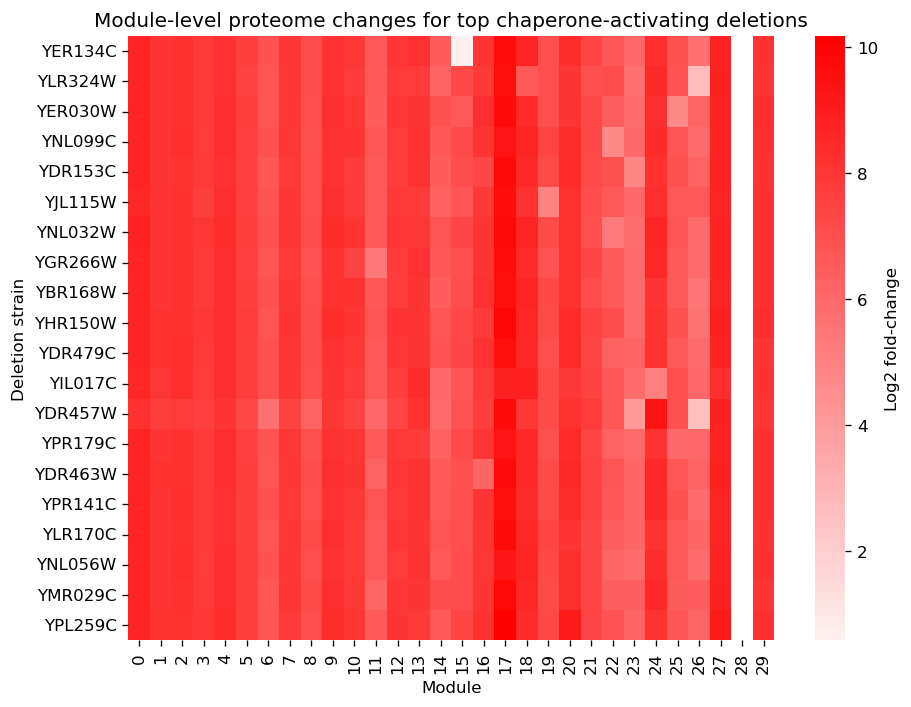

In [31]:
# Cell 8 – Heatmap of module‑level responses for top deletions
import seaborn as sns

subset = top_activators.index[:50]
heatmap_data = module_avg_df.loc[subset, modules]

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, cmap="bwr", center=0, cbar_kws={"label": "Log2 fold-change"})
plt.xlabel("Module")
plt.ylabel("Deletion strain")
plt.title("Module-level proteome changes for top chaperone-activating deletions")
plt.tight_layout()
plt.show()

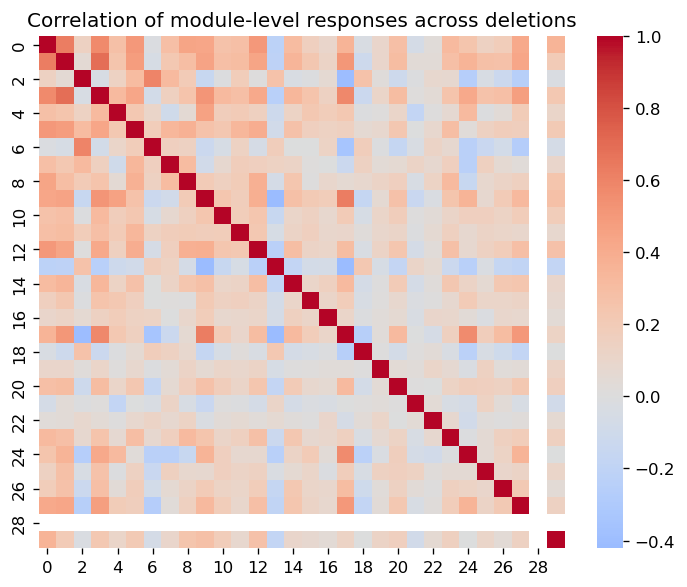

In [32]:
# Cell 9 – Correlation between modules across deletions
corr_df = module_avg_df[modules].corr(method="spearman")
plt.figure(figsize=(6, 5))
sns.heatmap(corr_df, cmap="coolwarm", center=0)
plt.title("Correlation of module-level responses across deletions")
plt.tight_layout()
plt.show()

In [33]:
# Cell 10 – Statistical tests
results = []
for m in modules:
    deletions_in_m = module_avg_df[module_avg_df["deletion_module"] == m]["chaperone_module_delta"]
    deletions_not_m = module_avg_df[module_avg_df["deletion_module"] != m]["chaperone_module_delta"]
    if len(deletions_in_m) > 0 and len(deletions_not_m) > 0:
        stat, p = mannwhitneyu(deletions_in_m, deletions_not_m, alternative="two-sided")
        results.append({"deletion_module": m, "p_value": p, "n_deletions": len(deletions_in_m)})
statistics_df = pd.DataFrame(results).sort_values("p_value")
statistics_df

,deletion_module,p_value,n_deletions
0,0,NaN,711
1,1,NaN,481
2,2,NaN,285
3,3,NaN,291
4,4,NaN,209
5,5,NaN,155
6,6,NaN,26
7,7,NaN,87
8,8,NaN,52
9,9,NaN,52
